# Informasi lingkungan

In [1]:
import os
import sys
import platform

print("Python       :", sys.version)
print("Sistem       :", platform.system())
print("Folder kerja :", os.getcwd())

Python       : 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
Sistem       : Windows
Folder kerja : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\notebooks


# Memuat library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import torch
import torchvision
import albumentations as A

from PIL import Image
from pathlib import Path

print("NumPy          :", np.__version__)
print("Pandas         :", pd.__version__)
print("OpenCV         :", cv2.__version__)
print("PyTorch        :", torch.__version__)
print("TorchVision    :", torchvision.__version__)
print("Albumentations :", A.__version__)
print("Semua library berhasil dimuat")

NumPy          : 2.4.6
Pandas         : 3.0.5
OpenCV         : 5.0.0
PyTorch        : 2.13.0+cu130
TorchVision    : 0.28.0+cu130
Albumentations : 2.0.8
Semua library berhasil dimuat


# Memeriksa CPU atau GPU

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Perangkat yang digunakan :", device)
print("CUDA tersedia            :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nama GPU                  :", torch.cuda.get_device_name(0))
    print("Jumlah GPU                :", torch.cuda.device_count())
else:
    print("Training sementara menggunakan CPU")

Perangkat yang digunakan : cpu
CUDA tersedia            : False
Training sementara menggunakan CPU


# Menetapkan lokasi folder proyek

In [6]:
PROJECT_DIR = Path("/app")
DATASET_DIR = PROJECT_DIR / "dataset"
RAW_DIR = DATASET_DIR / "raw"
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"
MODEL_DIR = PROJECT_DIR / "models"
LOG_DIR = PROJECT_DIR / "logs"

directories = {
    "Project": PROJECT_DIR,
    "Dataset": DATASET_DIR,
    "Raw": RAW_DIR,
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR,
    "Model": MODEL_DIR,
    "Log": LOG_DIR,
}

for name, path in directories.items():
    print(f"{name:12}: {path} | tersedia: {path.exists()}")

Project     : /app | tersedia: True
Dataset     : /app/dataset | tersedia: True
Raw         : /app/dataset/raw | tersedia: True
Train       : /app/dataset/train | tersedia: True
Validation  : /app/dataset/val | tersedia: True
Test        : /app/dataset/test | tersedia: True
Model       : /app/models | tersedia: True
Log         : /app/logs | tersedia: True


In [7]:
zip_path = RAW_DIR / "GCD.zip"

print("Lokasi dataset :", zip_path)
print("File tersedia  :", zip_path.exists())

if zip_path.exists():
    ukuran_mb = zip_path.stat().st_size / (1024 * 1024)
    print(f"Ukuran file    : {ukuran_mb:.2f} MB")
else:
    print("GCD.zip belum ditemukan di folder dataset/raw")

Lokasi dataset : /app/dataset/raw/GCD.zip
File tersedia  : True
Ukuran file    : 175.24 MB


In [10]:
import zipfile

zip_path = RAW_DIR / "GCD.zip"
extract_dir = RAW_DIR / "GCD"

if not zip_path.exists():
    print("GCD.zip belum ditemukan.")
elif extract_dir.exists() and any(extract_dir.iterdir()):
    print("Dataset sudah pernah diekstrak:", extract_dir)
else:
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print("Ekstraksi dataset selesai:", extract_dir)

Dataset sudah pernah diekstrak: /app/dataset/raw/GCD


In [11]:
def tampilkan_struktur(folder, batas=50):
    folder = Path(folder)

    if not folder.exists():
        print("Folder tidak ditemukan:", folder)
        return

    items = list(folder.rglob("*"))

    print("Folder :", folder)
    print("Jumlah item:", len(items))
    print()

    for item in items[:batas]:
        tipe = "DIR " if item.is_dir() else "FILE"
        print(f"{tipe} | {item.relative_to(folder)}")

    if len(items) > batas:
        print(f"\nMenampilkan {batas} dari {len(items)} item.")

tampilkan_struktur(extract_dir)

Folder : /app/dataset/raw/GCD
Jumlah item: 19017

DIR  | GCD
DIR  | GCD/test
DIR  | GCD/train
DIR  | GCD/test/1_cumulus
DIR  | GCD/test/2_altocumulus
DIR  | GCD/test/3_cirrus
DIR  | GCD/test/4_clearsky
DIR  | GCD/test/5_stratocumulus
DIR  | GCD/test/6_cumulonimbus
DIR  | GCD/test/7_mixed
FILE | GCD/test/1_cumulus/1_cumulus_000776.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000777.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000778.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000779.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000780.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000781.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000782.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000783.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000784.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000785.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000786.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000787.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000788.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000789.jpg
FILE | GCD/test/1_cumulus/1_cumulus_000790.jpg
FILE |

In [12]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_files = [
    file
    for file in extract_dir.rglob("*")
    if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
]

print("Jumlah seluruh citra:", len(image_files))

for file in image_files[:10]:
    print(file.relative_to(extract_dir))

Jumlah seluruh citra: 19000
GCD/test/1_cumulus/1_cumulus_000776.jpg
GCD/test/1_cumulus/1_cumulus_000777.jpg
GCD/test/1_cumulus/1_cumulus_000778.jpg
GCD/test/1_cumulus/1_cumulus_000779.jpg
GCD/test/1_cumulus/1_cumulus_000780.jpg
GCD/test/1_cumulus/1_cumulus_000781.jpg
GCD/test/1_cumulus/1_cumulus_000782.jpg
GCD/test/1_cumulus/1_cumulus_000783.jpg
GCD/test/1_cumulus/1_cumulus_000784.jpg
GCD/test/1_cumulus/1_cumulus_000785.jpg


Nama file : 1_cumulus_000776.jpg
Ukuran    : (512, 512)
Mode      : RGB


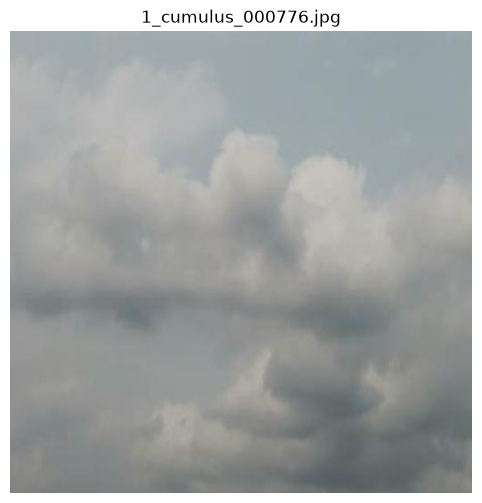

In [13]:
if image_files:
    sample_path = image_files[0]
    sample_image = Image.open(sample_path).convert("RGB")

    print("Nama file :", sample_path.name)
    print("Ukuran    :", sample_image.size)
    print("Mode      :", sample_image.mode)

    plt.figure(figsize=(8, 6))
    plt.imshow(sample_image)
    plt.title(sample_path.name)
    plt.axis("off")
    plt.show()
else:
    print("Belum ada citra yang ditemukan.")